[[ 8.73802634  9.05002843]
 [ 8.68802634  9.9927422 ]
 [ 9.59303156 11.15149454]
 [10.70543381 12.45795508]]


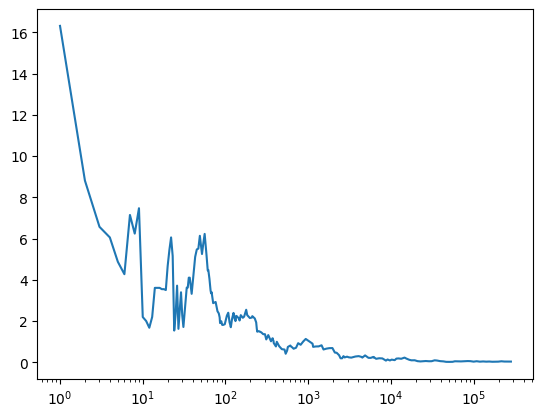

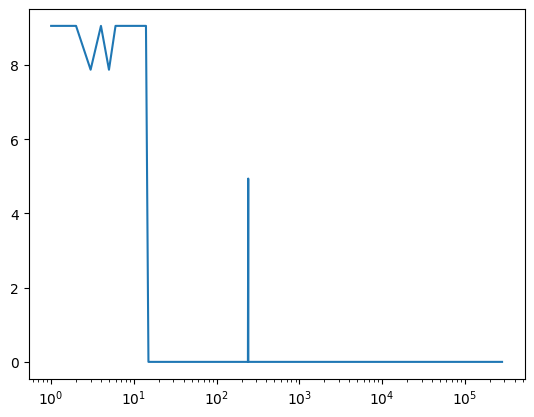

In [143]:
import numpy as np
import matplotlib.pyplot as plt

L     = 4          
gamma = 0.96


def build_riverswim(L=4):
    S = L
    A = 2
    P = np.zeros((S, A, S))
    R = np.zeros((S, A))

    for s in range(S):
        if s == 0:
            P[s, 0, 0] = 1.0          
            R[s, 0]    = 0.05         
        else:
            P[s, 0, s - 1] = 1.0      

        if s == S - 1:                   
            P[s, 1, s]     = 0.6
            P[s, 1, s - 1] = 0.4
            R[s, 1]        = 1.0     
        elif s == 0:                     
            P[s, 1, s]     = 0.6
            P[s, 1, s + 1] = 0.4
        else:                            
            P[s, 1, s - 1] = 0.05
            P[s, 1, s]     = 0.55
            P[s, 1, s + 1] = 0.40
    
    return P, R


def step(s, a, P, R):
    next_state = np.random.choice(len(P[s, a]), p=P[s, a])
    reward = R[s, a]
    return next_state, reward

P, R = build_riverswim(4)



def greedy(Q, s,eps):
    if np.random.rand() < eps:
        return np.random.binomial(1,0.5)
    else:
        return np.argmax(Q[s])

def qvi(P, R, gamma, tol=10**-6):
    S, A = R.shape
    Q = np.zeros((S, A))
    while True:
        V = Q.max(axis=1)               
        Q_new = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Q_new[s, a] = R[s, a] + gamma * sum(P[s, a, n] * V[n] for n in range(S))
        if np.max(np.abs(Q_new - Q)) < tol:
            return Q_new
        Q = Q_new

Q_star = qvi(P,R,0.96)

def policy_eval(pi, P, R, gamma):
    S = len(pi)
    P_pi = P[np.arange(S), pi, :]        # (S, S) transition matrix under pi
    R_pi = R[np.arange(S), pi]           # (S,) reward vector under pi
    V_pi = np.linalg.solve(np.eye(S) - gamma * P_pi, R_pi)  # exact solve
    Q_pi_0_right = R[0, 1] + gamma * P[0, 1, :] @ V_pi      # Q^pi(s=0, a=right)
    return Q_pi_0_right


def ce_opo(P, R, Q_star,gamma = 0.96, T=300000, epsilon=0.15, alpha=0.25, beta=1.1):
    S, A, _ = P.shape
    
    N_sa_s = np.zeros((S, A, S))
    N_sa   = np.zeros((S, A))
    sum_r  = np.zeros((S, A))
    
    Q_hat = np.zeros((S, A))
    s = 0
    N_sa_last_update = np.ones((S, A))
    times, q_errors, return_losses = [], [], []
    
    for t in range(T):
        a = greedy(Q_hat, s, epsilon)
        s_next, r = step(s, a, P, R)
        
        N_sa_s[s, a, s_next] += 1
        N_sa[s, a]            += 1
        sum_r[s, a]           += r
        
        if np.any(N_sa >= beta * N_sa_last_update):
            P_hat = (N_sa_s + alpha) / (N_sa[:, :, np.newaxis] + alpha * S)
            R_hat = (alpha + sum_r) / (alpha + N_sa)
            Q_hat = qvi(P_hat, R_hat, gamma)
            N_sa_last_update = N_sa.copy()
            
            
            pi_hat = Q_hat.argmax(axis=1)
            q_err = np.max(np.abs(Q_star - Q_hat))
            Q_pi_0_right = policy_eval(pi_hat, P, R, gamma)
            return_loss = Q_star[0, 1] - Q_pi_0_right
            
            times.append(t)
            q_errors.append(q_err)
            return_losses.append(return_loss)
        
        s = s_next
    
    return np.array(times), np.array(q_errors), np.array(return_losses)


x,y,z = ce_opo(P,R,Q_star)



print(Q_star)
plt.plot(x, y)
plt.xscale('log')
plt.show()

plt.plot(x, z)
plt.xscale('log')
plt.show()

[[5.26283007 5.43003133]
 [5.21283007 5.99565959]
 [5.75583321 6.690911  ]
 [6.42327456 7.47478732]]


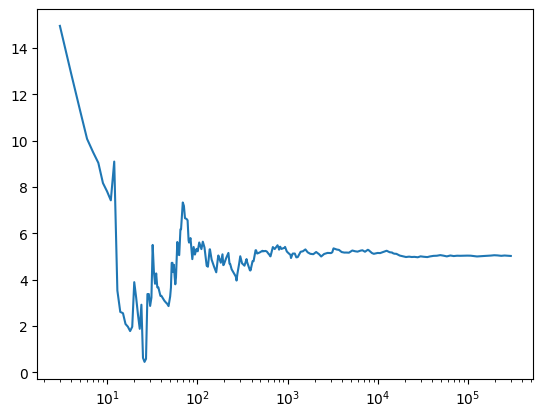

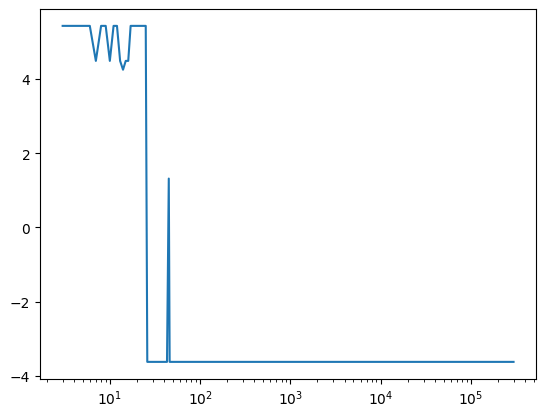

In [142]:
P_right = np.array([[0.6,0.4,0,0],
                    [0.05,0.55,0.4,0],
                    [0,0.05,0.55,0.4],
                    [0,0,0.4,0.6]])
P_left = np.array([[1,0,0,0],
                   [1,0,0,0],
                   [0,1,0,0],
                   [0,0,1,0]])
R = np.zeros((4,2,4))
R[0,0,0] = 0.05
R[3,1,3] = 1

def Q_star(T, gamma):
    Q = np.zeros((4, 2))
    R = np.zeros((4, 2))
    P = np.zeros((4, 2, 4))
    P[:,0,:] = P_left
    P[:,1,:] = P_right
    R[:, 0] = [0.05, 0 , 0, 0]
    R[:, 1] = [0, 0, 0, 0.6]
    for t in range(T):
        Q_prev = Q.copy()
        for s in range(4):
            for a in range(2):
                Q[s, a] = R[s, a] + gamma * np.sum(P[s, a, :] * np.max(Q_prev, axis=1))
    return Q

Q_star = Q_star(300000,0.96)

import numpy as np
import matplotlib.pyplot as plt

L     = 4          
gamma = 0.96


def build_riverswim(L=4):
    S = L
    A = 2
    P = np.zeros((S, A, S))
    R = np.zeros((S, A))

    for s in range(S):
        if s == 0:
            P[s, 0, 0] = 1.0          
            R[s, 0]    = 0.05         
        else:
            P[s, 0, s - 1] = 1.0      

        if s == S - 1:                   
            P[s, 1, s]     = 0.6
            P[s, 1, s - 1] = 0.4
            R[s, 1]        = 1.0     
        elif s == 0:                     
            P[s, 1, s]     = 0.6
            P[s, 1, s + 1] = 0.4
        else:                            
            P[s, 1, s - 1] = 0.05
            P[s, 1, s]     = 0.55
            P[s, 1, s + 1] = 0.40
    
    return P, R


def step(s, a, P, R):
    next_state = np.random.choice(len(P[s, a]), p=P[s, a])
    reward = R[s, a]
    return next_state, reward

P, R = build_riverswim(4)



def greedy(Q, s,eps):
    if np.random.rand() < eps:
        return np.random.binomial(1,0.5)
    else:
        return np.argmax(Q[s])

def qvi(P, R, gamma, tol=10**-6):
    S, A = R.shape
    Q = np.zeros((S, A))
    while True:
        V = Q.max(axis=1)               
        Q_new = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Q_new[s, a] = R[s, a] + gamma * sum(P[s, a, n] * V[n] for n in range(S))
        if np.max(np.abs(Q_new - Q)) < tol:
            return Q_new
        Q = Q_new

def policy_eval(pi, P, R, gamma):
    S = len(pi)
    P_pi = P[np.arange(S), pi, :]        # (S, S) transition matrix under pi
    R_pi = R[np.arange(S), pi]           # (S,) reward vector under pi
    V_pi = np.linalg.solve(np.eye(S) - gamma * P_pi, R_pi)  # exact solve
    Q_pi_0_right = R[0, 1] + gamma * P[0, 1, :] @ V_pi      # Q^pi(s=0, a=right)
    return Q_pi_0_right


def ce_opo(P, R, Q_star,gamma = 0.96, T=300000, epsilon=0.15, alpha=0.25, beta=1.1):
    S, A, _ = P.shape
    
    N_sa_s = np.zeros((S, A, S))
    N_sa   = np.zeros((S, A))
    sum_r  = np.zeros((S, A))
    
    Q_hat = np.zeros((S, A))
    s = 0
    N_sa_last_update = np.ones((S, A))
    times, q_errors, return_losses = [], [], []
    
    for t in range(T):
        a = greedy(Q_hat, s, epsilon)
        s_next, r = step(s, a, P, R)
        
        N_sa_s[s, a, s_next] += 1
        N_sa[s, a]            += 1
        sum_r[s, a]           += r
        
        if np.any(N_sa >= beta * N_sa_last_update):
            P_hat = (N_sa_s + alpha) / (N_sa[:, :, np.newaxis] + alpha * S)
            R_hat = (alpha + sum_r) / (alpha + N_sa)
            Q_hat = qvi(P_hat, R_hat, gamma)
            N_sa_last_update = N_sa.copy()
            
            
            pi_hat = Q_hat.argmax(axis=1)
            q_err = np.max(np.abs(Q_star - Q_hat))
            Q_pi_0_right = policy_eval(pi_hat, P, R, gamma)
            return_loss = Q_star[0, 1] - Q_pi_0_right
            
            times.append(t)
            q_errors.append(q_err)
            return_losses.append(return_loss)
        
        s = s_next
    
    return np.array(times), np.array(q_errors), np.array(return_losses)


x,y,z = ce_opo(P,R,Q_star)



print(Q_star)
plt.plot(x, y)
plt.xscale('log')
plt.show()

plt.plot(x, z)
plt.xscale('log')
plt.show()